# Gamma Kalibratie — `current_delay` verdeling

Doel: bepaal een zinvolle drempelwaarde gamma voor de dynamische prioriteitsupgrade.

**Aanpak:**
1. **Baseline** — geen herschikking (RF=∞): meet de ruwe `current_delay`-verdeling zoals de simulator die produceert
2. **Periodic RF=900** — met herschikking: meet dezelfde verdeling na interventie
3. **Analyse** — vergelijk verdelingen, bereken percentielkandidaten voor gamma

`current_delay(t)` = exit_delay op het laatste verlaten segment van trein t.
Uit `df` (output van `run_simulation`): alle `exit_delay`-waarden per trein per segment.


In [1]:
import sys, io, warnings
from pathlib import Path
from contextlib import redirect_stdout

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))

from run_simulation import run_simulation

# ── Parameters ─────────────────────────────────────────────────────────────
N_SEEDS   = 25
N_FREIGHT = 182

PERIODIC_RF  = 900

GAMMA_CANDIDATES = [60, 90, 120, 180, 240, 300]

print(f"Seeds      : {N_SEEDS}")
print(f"n_freight  : {N_FREIGHT}")
print(f"Periodic RF: {PERIODIC_RF}s")


Seeds      : 25
n_freight  : 182
Periodic RF: 900s


## 1. Helper — delay-records extraheren uit df

In [2]:
def extract_current_delays(df: pd.DataFrame, scenario: str, seed: int) -> pd.DataFrame:
    """
    Extraheert alle exit_delay waarden per (trein, segment) uit df.

    exit_delay op segment s = current_delay(train) op het moment dat de trein
    segment s verlaat. Dit is precies de waarde die instance.py gebruikt voor
    de upgrade-beslissing.

    Bewaart ook actual_exit als tijdstempel zodat we later per trigger-moment
    kunnen filteren.
    """
    # Alleen rijen waar actual_exit bekend is (trein heeft segment verlaten)
    complete = df.dropna(subset=["actual_exit", "exit_delay"]).copy()
    complete = complete[complete["exit_delay"].notna()]

    complete["scenario"] = scenario
    complete["seed"]     = seed

    return complete[[
        "train_id", "train_type", "train_subtype",
        "segment_id", "planned_exit", "actual_exit",
        "exit_delay", "scenario", "seed",
    ]]


def current_delays_at_triggers(df: pd.DataFrame, trigger_freq: float,
                                scenario: str, seed: int) -> pd.DataFrame:
    """
    Simuleert wat current_delay zou teruggeven op elk trigger-moment t.

    Voor elk trigger-tijdstip t = trigger_freq, 2*trigger_freq, ...:
      per trein: het meest recente segment dat voor t verlaten is,
      en zijn exit_delay.

    Dit is de exacte verdeling die de controller ziet bij elke aanroep.
    """
    complete = df.dropna(subset=["actual_exit", "exit_delay"]).copy()
    complete = complete[complete["exit_delay"].notna()].copy()

    sim_end   = complete["actual_exit"].max()
    triggers  = np.arange(trigger_freq, sim_end + trigger_freq, trigger_freq)

    records = []
    for t in triggers:
        # Per trein: laatste segment verlaten vóór t
        before_t = complete[complete["actual_exit"] <= t]
        if before_t.empty:
            continue
        last_per_train = (
            before_t.sort_values("actual_exit")
                     .groupby(["train_id", "train_type"])
                     .last()
                     .reset_index()
        )
        last_per_train["trigger_time"] = t
        last_per_train["scenario"]     = scenario
        last_per_train["seed"]         = seed
        records.append(last_per_train[[
            "train_id", "train_type", "trigger_time",
            "exit_delay", "scenario", "seed",
        ]])

    return pd.concat(records, ignore_index=True) if records else pd.DataFrame()


## 2. Runs uitvoeren

In [3]:
# ── Periodic RF=900 ─────────────────────────────────────────────────────────
print("=== PERIODIC RF=900 ===")
periodic_records  = []
periodic_triggers = []

for seed in range(N_SEEDS):
    buf = io.StringIO()
    with redirect_stdout(buf):
        _, df, meta, _ ,_= run_simulation(
            n_freight            = N_FREIGHT,
            trigger_strategy     = "periodic",
            periodic_freq        = PERIODIC_RF,
            event_driven_freq    = PERIODIC_RF,
            controller_freq      = PERIODIC_RF,
            threshold_confidence = 0.60,
            objective_strategy   = "static",
            weight_passenger     = 1,
            weight_freight       = 1,
            dynamic_threshold    = 120,
            min_objective_improvement = -10000.0,
            use_retracking       = True,
            seed                 = seed,
            save                 = False,
        )

    n_resc = meta["controller_summary"]["n_rescheduled"]
    periodic_records.append(extract_current_delays(df, "periodic_900", seed))
    periodic_triggers.append(current_delays_at_triggers(
        df, PERIODIC_RF, "periodic_900", seed
    ))

    if (seed + 1) % 5 == 0:
        print(f"  seed {seed+1:2d}/{N_SEEDS} klaar  (n_resc={n_resc})")

df_periodic      = pd.concat(periodic_records,  ignore_index=True)
df_peri_triggers = pd.concat(periodic_triggers, ignore_index=True)
print(f"\nPeriodic: {len(df_periodic):,} segment-exits  |  "
      f"{len(df_peri_triggers):,} trigger-observaties")


=== PERIODIC RF=900 ===
  seed  5/25 klaar  (n_resc=94)
  seed 10/25 klaar  (n_resc=94)
  seed 15/25 klaar  (n_resc=36)
  seed 20/25 klaar  (n_resc=94)
  seed 25/25 klaar  (n_resc=94)

Periodic: 259,667 segment-exits  |  1,282,344 trigger-observaties


## 3. Analyse

### 3.1 Percentielentabel — passenger trains, op trigger-momenten

Dit is de kernverdeling voor gamma-kalibratie: wat ziet de controller op elk
trigger-moment als `current_delay` voor passagierstreinen?


In [4]:
PCTS = [25, 50, 60, 75, 80, 90, 95, 99]

def pct_table(df_trig: pd.DataFrame, label: str) -> pd.DataFrame:
    pax = df_trig[
        (df_trig["train_type"] == "P") & (df_trig["exit_delay"] > 0)
    ]["exit_delay"]

    row = {"scenario": label, "n_obs": len(pax), "mean": pax.mean(), "std": pax.std()}
    for p in PCTS:
        row[f"p{p}"] = np.percentile(pax, p)
    return pd.DataFrame([row])

tbl = pd.concat([
    pct_table(df_peri_triggers, "Periodic RF=900"),
], ignore_index=True).set_index("scenario").round(1)

print("Verdeling current_delay voor PASSAGIERSTREINEN op trigger-momenten")
print("(alleen positieve vertragingen, in seconden)")
display(tbl)


Verdeling current_delay voor PASSAGIERSTREINEN op trigger-momenten
(alleen positieve vertragingen, in seconden)


,n_obs,mean,std,p25,p50,p60,p75,p80,p90,p95,p99
scenario,,,,,,,,,,,
Periodic RF=900,471901,87.5,84.3,24.0,62.0,82.0,125.0,144.0,203.0,257.0,364.3


### 3.2 Activatiegraad per gamma-kandidaat

Welk percentage passagierstreinen zou upgrade krijgen bij elk gamma?

In [5]:
def activation_table(df_trig: pd.DataFrame, label: str) -> pd.DataFrame:
    pax = df_trig[df_trig["train_type"] == "P"]["exit_delay"].fillna(0)
    rows = []
    for g in GAMMA_CANDIDATES:
        pct_activated = 100 * (pax >= g).mean()
        rows.append({"gamma": g, "scenario": label, "pct_activated": round(pct_activated, 1)})
    return pd.DataFrame(rows)

act = pd.concat([
    activation_table(df_peri_triggers, "Periodic RF=900"),
], ignore_index=True)

pivot = act.pivot(index="gamma", columns="scenario", values="pct_activated")
print("% passagierstreinen met current_delay >= gamma (inclusief on-time treinen)")
display(pivot)
print()
print("NB: inclusief treinen met delay=0. Onderstaande tabel alleen voor vertraagde treinen:")

def activation_table_delayed(df_trig, label):
    pax = df_trig[(df_trig["exit_delay"] > 0)]["exit_delay"]
    rows = []
    for g in GAMMA_CANDIDATES:
        pct_activated = 100 * (pax >= g).mean()
        rows.append({"gamma": g, "scenario": label, "pct_activated": round(pct_activated, 1)})
    return pd.DataFrame(rows)

act2 = pd.concat([
    activation_table_delayed(df_peri_triggers, "Periodic RF=900"),
], ignore_index=True)
pivot2 = act2.pivot(index="gamma", columns="scenario", values="pct_activated")
print("% vertraagde passagierstreinen met current_delay >= gamma")
display(pivot2)


% passagierstreinen met current_delay >= gamma (inclusief on-time treinen)


scenario,Periodic RF=900
gamma,
60,23.9
90,17.3
120,12.4
180,6.4
240,2.9
300,1.3



NB: inclusief treinen met delay=0. Onderstaande tabel alleen voor vertraagde treinen:
% vertraagde passagierstreinen met current_delay >= gamma


scenario,Periodic RF=900
gamma,
60,52.5
90,36.5
120,26.3
180,13.0
240,5.8
300,2.7


### 3.3 Verdeling — histogram + KDE per scenario

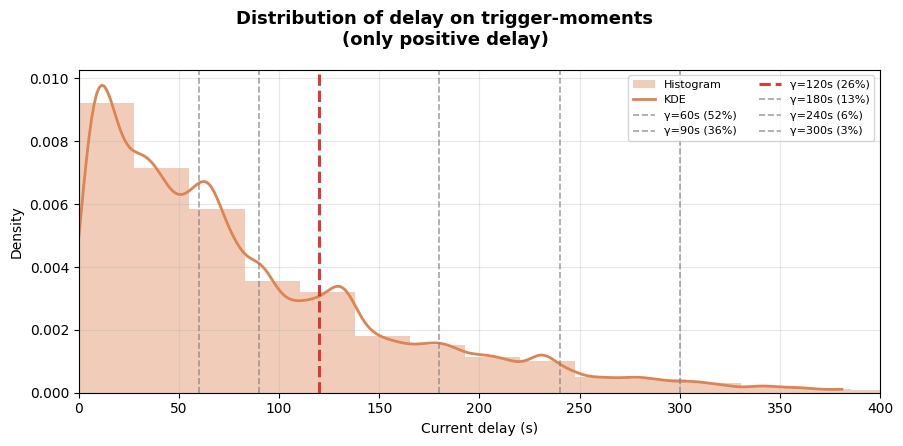

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))

fig.suptitle(
    "Distribution of delay on trigger-moments\n"
    "(only positive delay)",
    fontsize=13,
    fontweight="bold"
)

datasets = [
    (df_peri_triggers, "Periodic RF=900", "#DD8452"),
]

for df_t, label, color in datasets:

    pax = df_t[(df_t["exit_delay"] > 0)]["exit_delay"]

    # Histogram
    ax.hist(
        pax,
        bins=60,
        density=True,
        alpha=0.4,
        color=color,
        label="Histogram"
    )

    # KDE
    try:
        kde = stats.gaussian_kde(pax)
        x = np.linspace(0, pax.quantile(0.99), 300)

        ax.plot(
            x,
            kde(x),
            color=color,
            linewidth=2,
            label="KDE"
        )

    except Exception:
        pass

    # Gamma thresholds
    for g in GAMMA_CANDIDATES:

        special = (g == 120)

        ax.axvline(
            g,
            linestyle="--",
            linewidth=2.2 if special else 1.2,
            alpha=0.9 if special else 0.7,
            color="#D62728" if special else "#7F7F7F",
            label=f"γ={g}s ({100*(pax >= g).mean():.0f}%)"
        )

    # Styling
    ax.set_xlabel("Current delay (s)")
    ax.set_ylabel("Density")
    # ax.set_title(label, fontweight="bold")
    ax.set_xlim(left=0)

    ax.legend(fontsize=8, ncol=2)
    ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "gamma_calibration_distributions.png",
    dpi=150,
    bbox_inches="tight"
)
ax.set_xlim(0, 400)
plt.show()

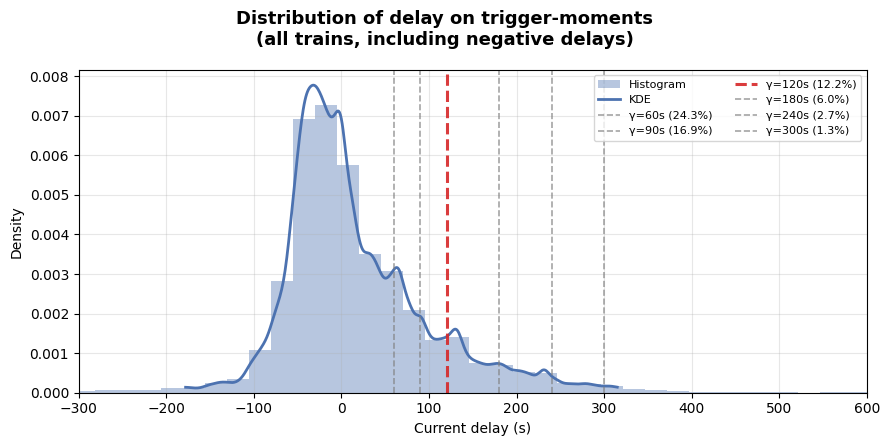

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))

fig.suptitle(
    "Distribution of delay on trigger-moments\n"
    "(all trains, including negative delays)",
    fontsize=13,
    fontweight="bold"
)

datasets = [
    (df_peri_triggers, "Periodic RF=900", "#4C72B0"),
]

for df_t, label, color in datasets:

    # ALL trains + include negative and zero delays
    delays = df_t["exit_delay"].fillna(0)

    # Histogram
    ax.hist(
        delays,
        bins=80,
        density=True,
        alpha=0.4,
        color=color,
        label="Histogram"
    )

    # KDE
    try:
        kde = stats.gaussian_kde(delays)

        x = np.linspace(
            delays.quantile(0.01),
            delays.quantile(0.99),
            500
        )

        ax.plot(
            x,
            kde(x),
            color=color,
            linewidth=2,
            label="KDE"
        )

    except Exception:
        pass

    # Gamma thresholds
    for g in GAMMA_CANDIDATES:

        special = (g == 120)

        pct = 100 * (delays >= g).mean()

        ax.axvline(
            g,
            linestyle="--",
            linewidth=2.2 if special else 1.2,
            alpha=0.9 if special else 0.7,
            color="#D62728" if special else "#7F7F7F",
            label=f"γ={g}s ({pct:.1f}%)"
        )

    # Styling
    ax.set_xlabel("Current delay (s)")
    ax.set_ylabel("Density")

    ax.set_xlim(-300, 600)

    ax.legend(fontsize=8, ncol=2)
    ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "gamma_calibration_all_trains.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### 3.4 Boxplot per treintype — baseline vs periodic

In [8]:
all_delays = df_trig["exit_delay"].fillna(0)

for g in GAMMA_CANDIDATES:
    pct = 100 * (all_delays >= g).mean()
    print(f"γ={g}s → {pct:.1f}%")

NameError: name 'df_trig' is not defined

In [ ]:
def activation_table_all(df_trig, label):

    all_delays = df_trig["exit_delay"].fillna(0)

    rows = []

    for g in GAMMA_CANDIDATES:

        pct_activated = 100 * (all_delays >= g).mean()

        rows.append({
            "gamma": g,
            "scenario": label,
            "pct_activated": round(pct_activated, 1)
        })

    return pd.DataFrame(rows)

act_all = pd.concat([
    activation_table_all(df_peri_triggers, "Periodic RF=900"),
], ignore_index=True)

pivot_all = act_all.pivot(
    index="gamma",
    columns="scenario",
    values="pct_activated"
)

print("% ALL trains with current_delay >= gamma")
display(pivot_all)

NameError: name 'df_baseline' is not defined

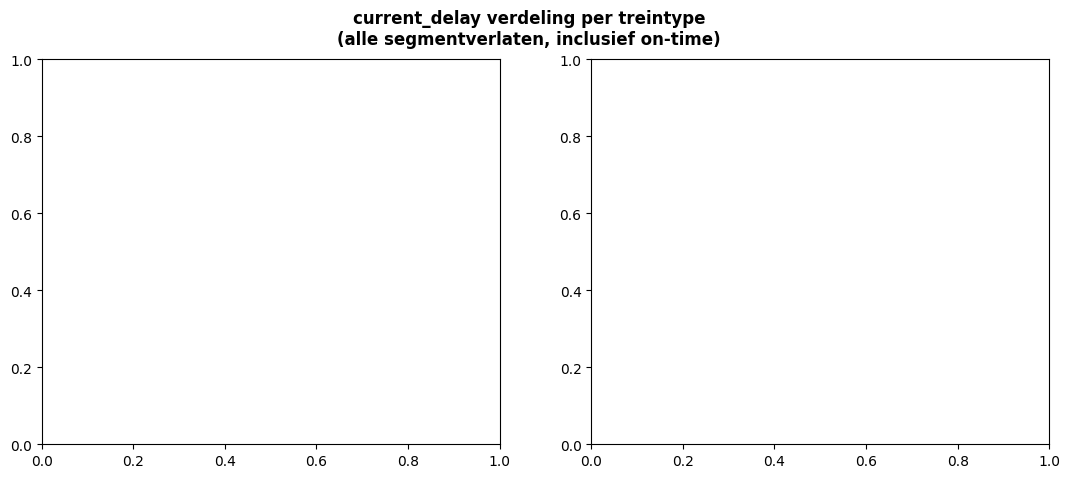

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("current_delay verdeling per treintype\n"
             "(alle segmentverlaten, inclusief on-time)", fontsize=12, fontweight="bold")

all_records = pd.concat([df_baseline, df_periodic], ignore_index=True)

for ax, scenario, color in zip(
    axes,
    ["baseline", "periodic_900"],
    ["#4C72B0", "#DD8452"],
):
    sub = all_records[all_records["scenario"] == scenario]
    data = [
        sub[sub["train_type"] == "P"]["exit_delay"].dropna().values,
        sub[sub["train_type"] == "F"]["exit_delay"].dropna().values,
    ]
    bp = ax.boxplot(data, patch_artist=True,
                    medianprops=dict(color="black", linewidth=2),
                    flierprops=dict(marker=".", markersize=2, alpha=0.3),
                    showfliers=True)
    for patch, c in zip(bp["boxes"], ["#95C8D8", "#F4A582"]):
        patch.set_facecolor(c); patch.set_alpha(0.8)

    for g in [60, 120, 180]:
        ax.axhline(g, linestyle="--", linewidth=1, alpha=0.6,
                   color="red", label=f"γ={g}s")

    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Passenger", "Freight"])
    ax.set_ylabel("exit_delay (s)")
    ax.set_title(scenario.replace("_", " ").title(), fontweight="bold")
    ax.set_ylim(bottom=0)
    ax.grid(axis="y", alpha=0.3)

axes[0].legend(fontsize=8)
plt.tight_layout()
plt.savefig("gamma_calibration_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()


### 3.5 Aanbeveling gamma

In [ ]:
print("=" * 60)
print("GAMMA AANBEVELING")
print("=" * 60)

for scenario_label, df_t in [
    ("Baseline (RF=∞)",  df_base_triggers),
    ("Periodic RF=900",  df_peri_triggers),
]:
    pax = df_t[(df_t["train_type"] == "P") & (df_t["exit_delay"] > 0)]["exit_delay"]
    print(f"\n{scenario_label}  (n={len(pax):,} observaties, vertraagde pax):")
    print(f"  Mediaan  (p50): {np.percentile(pax, 50):.0f}s")
    print(f"  p75           : {np.percentile(pax, 75):.0f}s")
    print(f"  p90           : {np.percentile(pax, 90):.0f}s")
    print()
    print("  Activatiegraad per gamma-kandidaat:")
    for g in GAMMA_CANDIDATES:
        pct = 100 * (pax >= g).mean()
        bar = "█" * int(pct / 2)
        print(f"    γ={g:>4}s → {pct:5.1f}% geüpgraded  {bar}")

print()
print("Vuistregel: kies gamma zodat 20-35% van vertraagde passagierstreinen")
print("de upgrade krijgt — genoeg om effect te hebben, niet zo laag dat")
print("bijna iedereen geüpgraded wordt (dan ≈ no_priority).")


GAMMA AANBEVELING

Baseline (RF=∞)  (n=595,467 observaties, vertraagde pax):
  Mediaan  (p50): 70s
  p75           : 139s
  p90           : 234s

  Activatiegraad per gamma-kandidaat:
    γ=  60s →  55.4% geüpgraded  ███████████████████████████
    γ=  90s →  41.2% geüpgraded  ████████████████████
    γ= 120s →  30.7% geüpgraded  ███████████████
    γ= 180s →  17.6% geüpgraded  ████████
    γ= 240s →   9.5% geüpgraded  ████
    γ= 300s →   5.9% geüpgraded  ██

Periodic RF=900  (n=581,119 observaties, vertraagde pax):
  Mediaan  (p50): 68s
  p75           : 138s
  p90           : 226s

  Activatiegraad per gamma-kandidaat:
    γ=  60s →  54.8% geüpgraded  ███████████████████████████
    γ=  90s →  40.6% geüpgraded  ████████████████████
    γ= 120s →  30.2% geüpgraded  ███████████████
    γ= 180s →  16.9% geüpgraded  ████████
    γ= 240s →   8.7% geüpgraded  ████
    γ= 300s →   4.5% geüpgraded  ██

Vuistregel: kies gamma zodat 20-35% van vertraagde passagierstreinen
de upgrade krijgt — 

---
## 4. Gamma-test — valideer gekozen waarde

Vergelijkt `dynamic` (met gekozen gamma) tegen `static` over `N_TEST_SEEDS` seeds.
Metrics: activatiegraad upgrade per run, delay_ratio, TED_combined.

Pas `GAMMA_TEST` aan om andere waarden te proberen.

In [ ]:
# ── Instelbare parameters ───────────────────────────────────────────────────
GAMMA_TEST    = 120   # ← pas hier aan (aanbeveling: 120s)
N_TEST_SEEDS  = 20
TRIGGER_CFG   = dict(
    trigger_strategy     = 'periodic',
    periodic_freq        = 900,
    event_driven_freq    = 900,
    controller_freq      = 900,
    threshold_confidence = 0.60,
)

from utils.metrics import compute_metrics

results = []

for seed in range(N_TEST_SEEDS):
    for strategy, label, gamma_val in [
        ('static',  'static',              None),
        ('dynamic', f'dynamic_g{GAMMA_TEST}', GAMMA_TEST),
    ]:
        buf = io.StringIO()
        with redirect_stdout(buf):
            _, df_run, meta, _, _ = run_simulation(
                n_freight          = N_FREIGHT,
                objective_strategy = strategy,
                weight_passenger   = 2,
                weight_freight     = 1,
                dynamic_threshold  = gamma_val if gamma_val else 999_999,
                seed               = seed,
                save               = False,
                **TRIGGER_CFG,
            )

        m    = compute_metrics(df_run)
        ctrl = meta['controller_summary']

        # Activatiegraad: hoeveel pax-treinen zouden gamma overschrijden?
        # Benadering via df_run: exit_delay van pax-treinen
        pax_delays = (
            df_run[df_run['train_type'] == 'P']
            .dropna(subset=['exit_delay'])
            ['exit_delay']
        )
        n_pax_delayed  = (pax_delays > 0).sum()
        n_pax_upgraded = (pax_delays >= GAMMA_TEST).sum() if gamma_val else 0
        pct_upgraded   = 100 * n_pax_upgraded / n_pax_delayed if n_pax_delayed > 0 else 0

        results.append({
            'seed':            seed,
            'strategy':        label,
            'TED_combined':    m.get('TED_combined'),
            'TED_passenger':   m.get('TED_passenger'),
            'TED_freight':     m.get('TED_freight'),
            'delay_ratio':     m.get('delay_ratio'),
            'n_rescheduled':   ctrl['n_rescheduled'],
            'pct_upgraded':    round(pct_upgraded, 1),
        })

    if (seed + 1) % 5 == 0:
        print(f'seed {seed+1:2d}/{N_TEST_SEEDS} klaar')

df_test = pd.DataFrame(results)
print(f'\nKlaar. gamma={GAMMA_TEST}s  |  {N_TEST_SEEDS} seeds per strategie')



Interrupt request received


Gamma = 120s  |  20 seeds


,TED_combined_mean,TED_combined_std,TED_passenger_mean,TED_freight_mean,delay_ratio_mean,delay_ratio_std,pct_upgraded_mean,n_rescheduled_mean
strategy,,,,,,,,
dynamic_g120,74036.55,3651.87,61655.97,12380.57,1.14,0.17,15.02,93.7
static,72475.57,8577.18,60323.82,12151.75,1.13,0.18,0.00,92.0



Dynamic vs Static (per seed, gamma=120s):
  ΔTED_combined : +1561s  (std 9167s)
  Δdelay_ratio  : +0.009   (std 0.088)
  Seeds dynamic beter op TED : 8/20
  Seeds dynamic lager DR     : 11/20
  Gemiddeld 15.0% pax-delays >= gamma per run


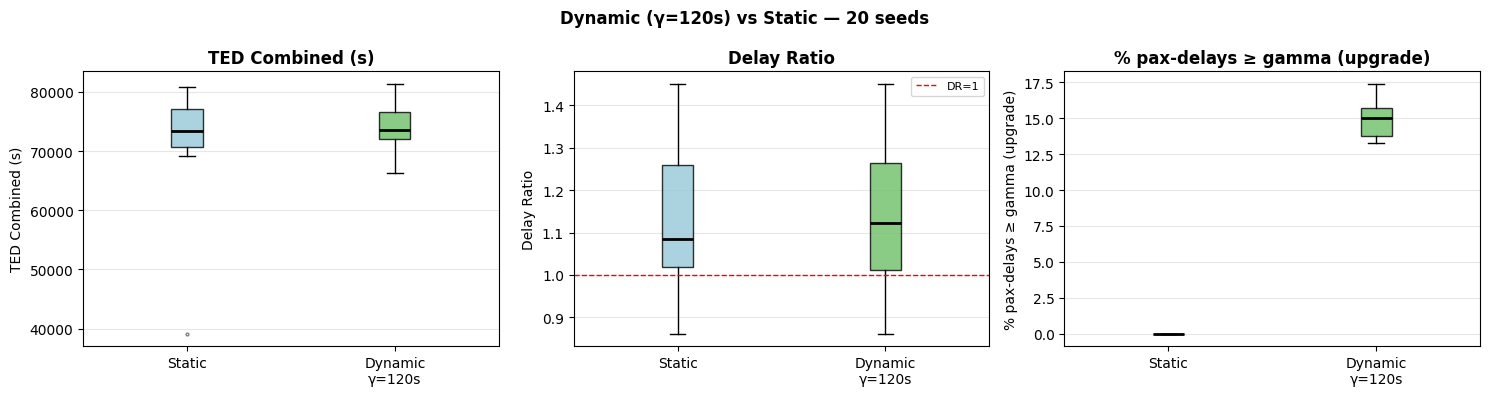

In [ ]:
# ── Vergelijkingstabel ──────────────────────────────────────────────────────
summary = (
    df_test.groupby('strategy')
    .agg(
        TED_combined_mean  = ('TED_combined',  'mean'),
        TED_combined_std   = ('TED_combined',  'std'),
        TED_passenger_mean = ('TED_passenger', 'mean'),
        TED_freight_mean   = ('TED_freight',   'mean'),
        delay_ratio_mean   = ('delay_ratio',   'mean'),
        delay_ratio_std    = ('delay_ratio',   'std'),
        pct_upgraded_mean  = ('pct_upgraded',  'mean'),
        n_rescheduled_mean = ('n_rescheduled', 'mean'),
    )
    .round(2)
)
print(f'Gamma = {GAMMA_TEST}s  |  {N_TEST_SEEDS} seeds')
display(summary)

# ── Pairwise vergelijking per seed ──────────────────────────────────────────
static_  = df_test[df_test['strategy'] == 'static'].set_index('seed')
dynamic_ = df_test[df_test['strategy'] == f'dynamic_g{GAMMA_TEST}'].set_index('seed')

diff_TED = dynamic_['TED_combined'] - static_['TED_combined']
diff_DR  = dynamic_['delay_ratio']  - static_['delay_ratio']

print(f'\nDynamic vs Static (per seed, gamma={GAMMA_TEST}s):')
print(f'  ΔTED_combined : {diff_TED.mean():+.0f}s  (std {diff_TED.std():.0f}s)')
print(f'  Δdelay_ratio  : {diff_DR.mean():+.3f}   (std {diff_DR.std():.3f})')
print(f'  Seeds dynamic beter op TED : {(diff_TED < 0).sum()}/{N_TEST_SEEDS}')
print(f'  Seeds dynamic lager DR     : {(diff_DR  < 0).sum()}/{N_TEST_SEEDS}')
print(f'  Gemiddeld {dynamic_["pct_upgraded"].mean():.1f}% pax-delays >= gamma per run')

# ── Plot ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'Dynamic (γ={GAMMA_TEST}s) vs Static — {N_TEST_SEEDS} seeds',
             fontsize=12, fontweight='bold')

for ax, col, label in zip(
    axes,
    ['TED_combined', 'delay_ratio', 'pct_upgraded'],
    ['TED Combined (s)', 'Delay Ratio', '% pax-delays ≥ gamma (upgrade)'],
):
    data_s = df_test[df_test['strategy'] == 'static'][col].dropna()
    data_d = df_test[df_test['strategy'] == f'dynamic_g{GAMMA_TEST}'][col].dropna()

    bp = ax.boxplot(
        [data_s, data_d],
        labels=['Static', f'Dynamic\nγ={GAMMA_TEST}s'],
        patch_artist=True,
        medianprops=dict(color='black', linewidth=2),
        flierprops=dict(marker='.', markersize=4, alpha=0.5),
    )
    for patch, c in zip(bp['boxes'], ['#95C8D8', '#6DBF67']):
        patch.set_facecolor(c); patch.set_alpha(0.8)

    if col == 'delay_ratio':
        ax.axhline(1.0, color='red', linestyle='--', linewidth=1, label='DR=1')
        ax.legend(fontsize=8)

    ax.set_ylabel(label)
    ax.set_title(label, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'gamma_test_{GAMMA_TEST}s.png', dpi=150, bbox_inches='tight')
plt.show()
